**2D**
1) Define the domain $\Omega$
2) Generate triangulations T_h
3) Construct finite element space V_h
4) Get local stiffness matrix A_k
5) Get local mass matrix M_k
6) Assemble local stiffness matrices into global stiffness matrix A
7) Assemble local mass matrices into a global mass matrix M
8) Impose Dirichlet Boundary Condition
9) Solve $A * u = \lambda * M * u$
10) Extract eigenvalues
11) compute the eigenvectors
12) Compare with exact solution


In [10]:
# 2D let the domain be uniform and defined on [0, 1]x[0, 1]
import numpy as np
from scipy.linalg import eigh
from scipy.spatial import Delaunay
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-poster")

In [3]:
# method for putting values on the main diagonal
def off_diag_values_matrix(rank, value):
       # the size should be smaller because there are less numbers off diagonal than on main diagonal
       diag = np.full(rank - 1, value)
       lower_off_centre_diag = np.diag(diag, k=-1)
       higher_off_centre_diag = np.diag(diag, k=1)

       matrix = lower_off_centre_diag + higher_off_centre_diag
       

       return matrix

# stiffness matrix
def stiffness_matrix_A(rank, h):
       # create a matrix (interior_nodes x interior_nodes) of zeros
       A = np.zeros((rank, rank), dtype=float)
       # diagonal values
       a_ii = 2 / h
       np.fill_diagonal(A, a_ii)
       # off diagonal values
       a_ij = -1 / h

       A = A + off_diag_values_matrix(rank, a_ij)
       return A

# mass matrix
def mass_matrix_M(rank, h):
       # create a matrix (interior_nodes x interior_nodes) of zeros
       M = np.zeros((rank, rank), dtype=float)
       # diagonal values
       m_ii = (4 * h) / 6
       np.fill_diagonal(M, m_ii)
       # off diagonal values
       m_ij = h / 6

       M = M + off_diag_values_matrix(rank, m_ij)
       return M

# error of all eigenvalues
# takes 2 lists of real eigenvalues and computed
def all_eigval_error(real_eigvals, comp_eigvals):
       # for values in both arrays
       for real_val, val in zip(real_eigvals, comp_eigvals):
              error = abs(real_val - val)
              print(
                     f"Computed eigenvalue: {val:.5f}\n",
                     f"Real value: {real_val:.5f}\n",
                     f"Error: {error:.5f}"
              )

# error of the first eigenvalue
# will get only the first elements of the arrays
def first_eigval_error(real_eigval, comp_eigval):
       error = abs(real_eigval - comp_eigval)
       return error

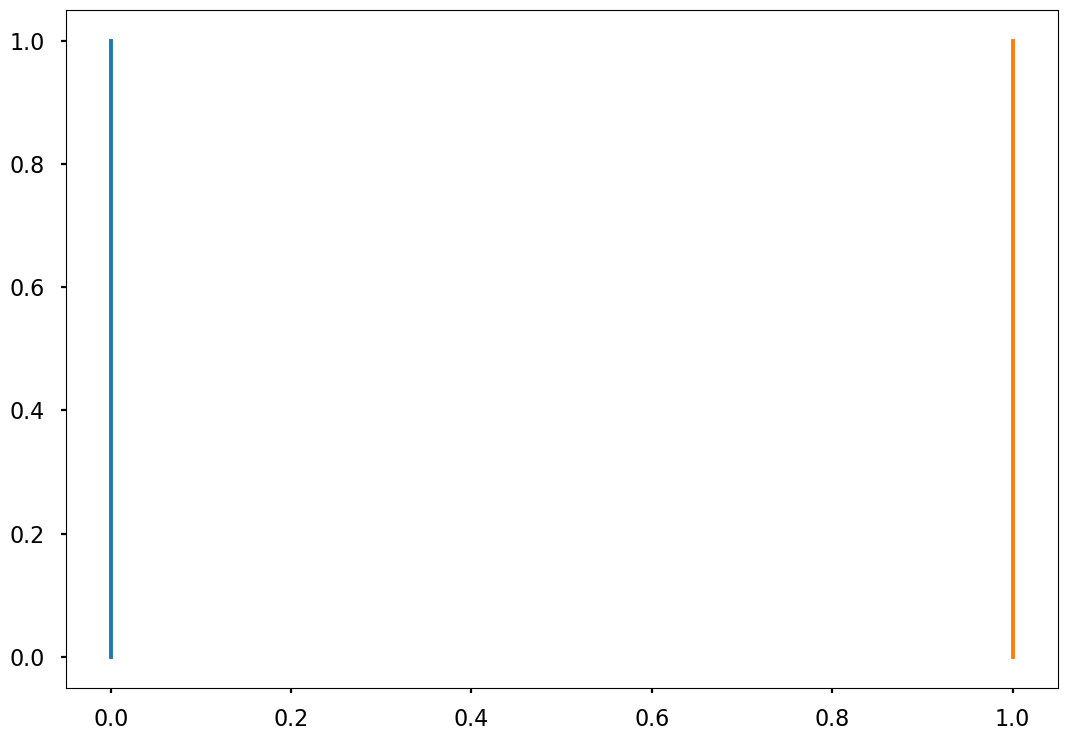

In [ ]:
# define the domain (unit square)
x_min, x_max = 0.0, 1.0
y_min, y_max = 0.0, 1.0
num_points = 2


# generate 2D domain
domain = np.array(
       [[0, 0], [1, 0],
       [0, 1], [1, 1]]
)
# create triangles on the domain
tri = Delaunay(domain)

# visualise the triangulations
#plt.triplot(domain[:,0], domain[:,1], tri.simplices.copy())
#plt.plot(domain[:,0], domain[:,1], "o")
#plt.show()


